In [1]:
import numpy as np
import torch.nn.functional as F
from matplotlib import pyplot as plt
import torch

import sys
import os
from scipy.stats import poisson

sys.path.insert(1, "/".join(os.path.abspath("").split("/")[0:-1]))
from main.distributions import GumbelSoftmaxPoisson

In [2]:
x = np.arange(5)

Text(0.02, 0.5, 'probability density')

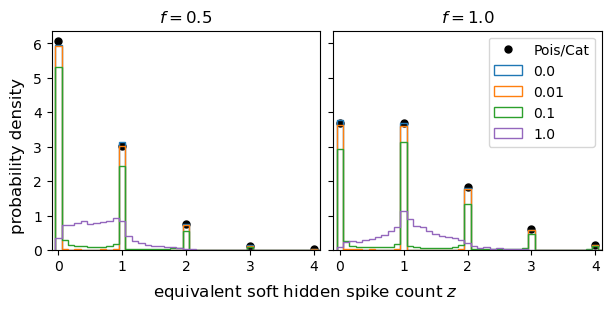

In [3]:
fig, axs = plt.subplots(1, 2, figsize=(6, 3), layout="constrained", sharey=True)
for i, mu in enumerate([0.5, 1.0]):
    axs[i].plot(x, 10 * poisson.pmf(x, mu), ".", markersize=10, label="Pois/Cat", c="k")
    for temp, c in [(0.0, "C0"), (0.01, "C1"), (0.1, "C2"), (1.0, "C4")]:
        gs_poisson = GumbelSoftmaxPoisson(
            log_rate=torch.tensor(mu).log(),
            temp=temp,
            upperbound_method="fixed",
            upperbound_param=5,
        )
        if temp == 0.0:
            soft_counts = gs_poisson.sample(10000).numpy()
        else:
            logit_pi = gs_poisson.logit_pi.detach().numpy()
            gs_samples = gs_poisson.rsample(10000)
            soft_counts = gs_poisson.aggregate_samples(gs_samples).numpy()
        axs[i].hist(
            soft_counts.flatten(),
            density=True,
            bins=np.arange(-0.05, 5, 0.1),
            color=c,
            label=temp,
            fill=False,
            histtype="step",
        )
    axs[i].set(title=f"$f = {mu}$", xlim=(-0.1, 4.1))
axs[1].legend()
fig.supxlabel("equivalent soft hidden spike count $z$")
fig.supylabel("probability density")
# fig.savefig('different_distributions.pdf', bbox_inches='tight', transparent=True)